# Train Multiple Autoencoders
In this notebook, we train multiple autoencoders with varying dimensions on the MNIST dataset.

## Setup


Set this to True if in Drive

In [7]:
inDrive = True

In [8]:
if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation')
else:
    # Add parent directory to path so we can import modules
    import sys
    import os

    # Get the current directory
    current_dir = os.path.dirname(os.path.abspath('__file__'))

    # Get the parent directory
    parent_dir = os.path.dirname(current_dir)

    # Add the parent directory to sys.path
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

Mounted at /content/drive


In [9]:
training = True

Import libraries

In [10]:
import importlib
import models.regene_models as regene_models
importlib.reload(regene_models)
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

Set the device

In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Load the Datasets

In [12]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
valset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)

Create a models directory if it doesn't exist

In [13]:
# Create models directory in parent directory if it doesn't exist
os.makedirs(os.path.join('..', 'model_saves'), exist_ok=True)
model_saves_path = os.path.join('..', 'model_saves')

## Load autoencoder

In [14]:
import importlib
import sys
sys.path.append('..')  # Add parent directory to path
from models.mnist_conv_autoencoder import MNISTConvAutoencoder
import models.mnist_conv_autoencoder  # Import the module first
importlib.reload(models.mnist_conv_autoencoder)

<module 'models.mnist_conv_autoencoder' from '/content/drive/My Drive/Hybrid-CLUE/MyImplementation/models/mnist_conv_autoencoder.py'>

In [15]:
dimensions = [16, 32, 64, 128, 256]

for latent_dim in dimensions:
    autoencoder_save_path = os.path.join(model_saves_path, f'mnist_conv_autoencoder_{latent_dim}.pth')
    autoencoder = MNISTConvAutoencoder(device=device, model_save_path=autoencoder_save_path, latent_dim=latent_dim)

    autoencoder.train_model(
        train_loader=trainloader,
        val_loader=valloader,
        num_epochs=20,
        lr=1e-3,
        patience=10,
        factor=0.5,
        min_lr=1e-6,
        loss_type='bce'
    )

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20, Train Loss: 0.135909, Val Loss: 0.098890, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 2/20, Train Loss: 0.095587, Val Loss: 0.091190, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 3/20, Train Loss: 0.090769, Val Loss: 0.089316, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 4/20, Train Loss: 0.088313, Val Loss: 0.087354, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 5/20, Train Loss: 0.086638, Val Loss: 0.085751, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 6/20, Train Loss: 0.085497, Val Loss: 0.085123, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 7/20, Train Loss: 0.084551, Val Loss: 0.083921, LR: 0.001000
Model saved to ../model_saves/mnist_conv_autoencoder_16.pth
Epoch 8/20, Train Loss: 0.083873, Val Loss: 0.083319, LR: 0.001000
Model saved to ../model_saves/mnist_conv_aut

In [ ]:
autoencoder.load_model()

Model loaded from ../model_saves/new_regene_models/mnist_conv_autoencoder.pth


MNISTConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=256, bias=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_dense): Sequential(
    (0): Linear(in_features=256, out_features=6272, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    

### Test autoencoder

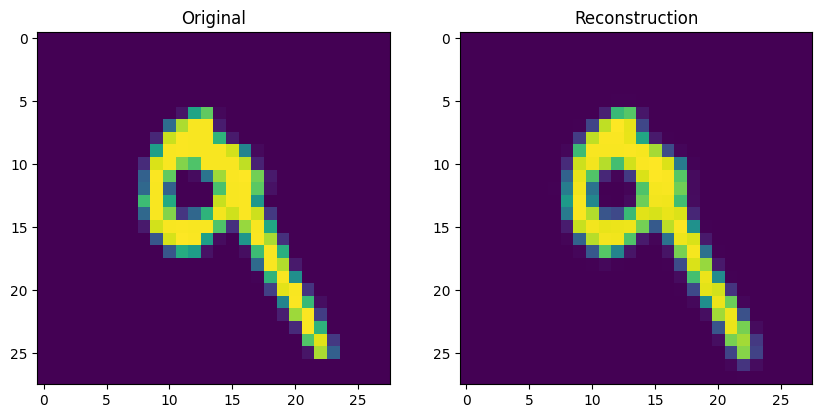

In [ ]:
test_img, test_label = testloader.dataset[7]

with torch.no_grad():
    test_img = test_img.unsqueeze(0).to(cfg.device)
    z = autoencoder.encode(test_img)
    recon = autoencoder.decode(z)

    # Plot original vs reconstruction
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_img[0].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(recon[0].cpu().permute(1, 2, 0))
    plt.title("Reconstruction")
    plt.show()